Nama: Callista Gianna Then

NIM: 2802498293

Kelas: LD-09

Dataset: B

Anda adalah seorang data scientist di sebuah institusi keuangan. Anda mendapati sebuah problem yang terjadi di institusi, dimana anda perlu menilai performa kredit setiap nasabah dengan menggunakan pendekatan data science. Anda diberikan akses kepada data yang diberikan sesuai ketentuan di atas. Dengan menggunakan data ini, maka anda perlu melakukan:

[LO 1, 2, 3, 4, 5 – 25 poin] Membuat model berbasis machine learning berdasarkan data dan
problem yang ingin diselesaikan. Pada bagian ini anda perlu untuk menjelaskan:

problem yang ingin diselesaikan. Pada bagian ini anda perlu untuk menjelaskan:

i. fitur yang digunakan

ii. pre prosesing yang dilakukan

iii. model machine learning

iv. evaluasi metrik yang digunakan

v. Anda juga perlu menjelaskan eksperimen apa yang dilakukan untuk mendapat model terbaik.
  
Anda akan mencoba beberapa model machine learning dalam setiap kali proses training.

## Loading Libraries

In [148]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer



from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


from sklearn.inspection import permutation_importance

## Data Loading

In [149]:
df = pd.read_csv("data_B.csv")

## Data Overview

In [150]:
df.shape

(25000, 29)

In [151]:
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [153]:
df.columns

Index(['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN',
       'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [154]:
duplicates = df[df.duplicated()]

print(f"Number of duplicate rows: {len(duplicates)}")
display(duplicates.head())

Number of duplicate rows: 0


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score


tidak ada duplicated rows

kalau di lihat sekilas, dataset kita berbentuk 25000 baris dan 29 kolum.

dimana beberapa dari kolum ini bernama:
- Unnamed
- ID
- Customer_ID
- Month
- Name
- Age
- SSN
- Occupation
- Annual_Income
- Monthly_Inhand_Salary
- Num_Bank_Accounts
- Num_Credit_Card
- Interest_Rate
- Num_of_Loan
- Type_of_Loan
- Delay_from_due_date
- Num_of_Delayed_Payment
- Changed_Credit_Limit
- Num_Credit_Inquiries
- Credit_Mix
- Outstanding_Debt
- Credit_Utilization_Ratio
- Credit_History_Age
- Payment_of_Min_Amount
- Total_EMI_per_month
- Amount_invested_monthly
- Payment_Behaviour
- Monthly_Balance
- Credit_Score




kolom-kolom yang tidak dibutuhkan, karena fitur-fitur ini tidak mempunyai impact kepada credit_score dan hanya bersifat sebagai UNIQUE IDENTIFIERS.

dia ngga memberikan kontribusi kepada prediction. Tidak ada artinya untuk credit_score

fitur-fitur yang tidak dibutuhkan, namun masih masuk ke dalam dataset dapat menyebabkan overfitting di berbagai kasus.

SSN --> Social Security Number
- 9-digit identification number
- biasanya random


KOLUM YANG NGGA DIPAKE: drop aja
- Unnamed
- ID
- Customer_ID
- Name
- SSN


In [155]:
print(df.columns.tolist())

['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


In [156]:
df = df.drop(columns=[
    'Unnamed: 0',
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
])

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22152 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24510 non-null  float64
 14  Credit

dari insight data.info(), kami bisa lihat kalau banyak inconsistencies yang ada dalam data kita, seperti null values, anomalies, atau perbedaan typing format yang dapat menimbulkan
- DataType yang tidak seharusnya

seperti:
- Age = object harusnya int
- Annual Income = object sebenernya bisa float

#### Summary Data Overview


- Dataset awal terdiri dari 25.000 baris dan 29 kolom, tanpa duplicated rows.
- Lima kolom bersifat unique identifier (Unnamed: 0, ID, Customer_ID, Name, SSN) --> di-drop karena hanya berfungsi sebagai penanda unik per baris, tidak merepresentasikan karakteristik finansial nasabah, sehingga tidak memiliki hubungan kausal terhadap Credit_Score.
- Hasil df.info() menunjukkan beberapa kolom numerik (Age, Annual_Income, dan lainnya) masih bertipe object --> mengindikasikan adanya karakter non-numerik (whitespace, simbol, underscore) di dalam data yang perlu dibersihkan sebelum kolom tersebut dapat diproses sebagai variabel numerik.

## Data Preprocessing

steps yg akan dilakukan buat bersihin data:
- missing values -- kalo relatively small, drop
- formatting anomalies -- leading / lagging space, random characters, random dash
- real value anomalies -- age tiba" dibawah 18 tahun (minimal 18 buat punya akun), age tiba" diatas 100


#### Inconsistent Values Format & Missing values


- FORMAT DULU buat kalo ada "", " ", "-", "_" jadi missing value
- cek persentase

kalo relatively small, missing value di dalam kolum tersebut < 5% , maka boleh di drop saja

In [158]:
df.isna().mean()*100

,0
Month,0.000
Age,0.000
Occupation,0.000
Annual_Income,0.000
Monthly_Inhand_Salary,15.024
Num_Bank_Accounts,0.000
Num_Credit_Card,0.000
Interest_Rate,0.000
Num_of_Loan,0.000
Type_of_Loan,11.392


In [159]:
df = df.replace(
    [
        "",
        " ",
        "  ",
        "-",
        "--",
        "N/A",
        "NA"
    ],
    np.nan)

In [160]:
df = df.replace(r'^_+$', np.nan, regex=True)  #kalo ada yang _ doang di suatu cell
#mau seberapa pun _ nya kalo cuman _, di jadiin missing value

In [161]:
numeric_cols = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

In [162]:
for col in numeric_cols:

    invalid = df[
        df[col].astype(str).str.contains(r'[A-Za-z]', na=False)
    ][col].unique()

    if len(invalid) > 0:
        print(f"\n{col}")
        print(invalid[:20])


Monthly_Inhand_Salary
[nan]

Num_of_Delayed_Payment
[nan]

Changed_Credit_Limit
[nan]

Num_Credit_Inquiries
[nan]

Amount_invested_monthly
[nan]

Monthly_Balance
[nan]


In [163]:
for col in numeric_cols:
    mask = ~df[col].astype(str).str.match(
        r'^-?\d*\.?\d+$',
        na=False)

    if mask.sum()> 0:
        print(f"\n{col}:{mask.sum()} inconsistencies")
        print(df.loc[mask, col].head(10).tolist())


Age:1244 inconsistencies
['39_', '29_', '44_', '39_', '46_', '48_', '36_', '17_', '43_', '41_']

Annual_Income:1749 inconsistencies
['120539.8_', '22433.46_', '46352.82_', '72902.70000000001_', '121813.72_', '160573.56_', '14179.49_', '42103.18_', '19604.35_', '14006.745_']

Monthly_Inhand_Salary:3756 inconsistencies
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Num_of_Loan:1201 inconsistencies
['6_', '9_', '2_', '6_', '4_', '4_', '2_', '2_', '0_', '7_']

Num_of_Delayed_Payment:2424 inconsistencies
[nan, '14_', nan, nan, nan, '23_', '23_', nan, nan, nan]

Changed_Credit_Limit:532 inconsistencies
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Num_Credit_Inquiries:490 inconsistencies
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Outstanding_Debt:229 inconsistencies
['2783.29_', '809.86_', '725.53_', '4921.57_', '708.2_', '340.22_', '1155.21_', '396.97_', '1438.91_', '839.1_']

Amount_invested_monthly:2189 inconsistencies
['__10000__', '__10000__', '__10000__', nan, nan,

In [164]:
for col in numeric_cols:

    df[col] = (df[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True))

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [165]:
for col in numeric_cols:

    mask = ~df[col].astype(str).str.match(
        r'^-?\d*\.?\d+$',
        na=False
    )

    if mask.sum() > 0:
        print(col, mask.sum())

Monthly_Inhand_Salary 3756
Num_of_Delayed_Payment 1733
Changed_Credit_Limit 532
Num_Credit_Inquiries 490
Amount_invested_monthly 1060
Monthly_Balance 303


In [166]:
df.isna().mean()*100

,0
Month,0.000
Age,0.000
Occupation,7.168
Annual_Income,0.000
Monthly_Inhand_Salary,15.024
Num_Bank_Accounts,0.000
Num_Credit_Card,0.000
Interest_Rate,0.000
Num_of_Loan,0.000
Type_of_Loan,11.392


In [167]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,April,32,Architect,14995.290,NaN,7,5,28,5,"Auto Loan, Payday Loan, Mortgage Loan, Payday ...",...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.738541,Low_spent_Medium_value_payments,278.586245,Poor
1,January,30,Lawyer,74902.800,6272.900000,8,8,33,9,"Auto Loan, Debt Consolidation Loan, Debt Conso...",...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.259012,High_spent_Large_value_payments,280.279454,Poor
2,January,22,Lawyer,20574.710,1813.559167,7,9,25,6,"Mortgage Loan, Mortgage Loan, Home Equity Loan...",...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.893082,Low_spent_Large_value_payments,284.702860,Poor
3,February,53,Writer,111090.060,9192.505000,0,125,11,3,"Payday Loan, Credit-Builder Loan, and Auto Loan",...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.737285,Low_spent_Medium_value_payments,613.433557,Standard
4,January,42,Teacher,19214.965,1730.247083,0,4,11,0,NaN,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.780472,!@9#%8,245.244236,Good


masih ada inconsistency !@9#%8 di Payment_Behaviour

cek inconsistencies lagi

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                23208 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              22152 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  float64
 12  Changed_Credit_Limit      24468 non-null  float64
 13  Num_Credit_Inquiries      24510 non-null  float64
 14  Credit

In [169]:
for col in df.select_dtypes(include='object'):
    print(f"\n{col}")
    print("Unique:", df[col].nunique())
    print(df[col].dropna().sample(5).tolist())


Month
Unique: 8
['June', 'April', 'May', 'August', 'August']

Occupation
Unique: 15
['Engineer', 'Lawyer', 'Writer', 'Entrepreneur', 'Teacher']

Type_of_Loan
Unique: 5747
['Personal Loan, Student Loan, Payday Loan, and Not Specified', 'Home Equity Loan, Personal Loan, Mortgage Loan, Student Loan, Not Specified, Payday Loan, and Payday Loan', 'Student Loan, Home Equity Loan, Payday Loan, and Student Loan', 'Payday Loan, Home Equity Loan, Payday Loan, and Auto Loan', 'Payday Loan, and Auto Loan']

Credit_Mix
Unique: 3
['Good', 'Standard', 'Bad', 'Standard', 'Standard']

Credit_History_Age
Unique: 404
['17 Years and 11 Months', '19 Years and 6 Months', '7 Years and 3 Months', '19 Years and 3 Months', '26 Years and 7 Months']

Payment_of_Min_Amount
Unique: 3
['Yes', 'NM', 'Yes', 'No', 'No']

Payment_Behaviour
Unique: 7
['Low_spent_Large_value_payments', '!@9#%8', 'High_spent_Medium_value_payments', 'Low_spent_Small_value_payments', 'Low_spent_Large_value_payments']

Credit_Score
Unique: 3

In [170]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts(dropna=False).head(20))


Month
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

Occupation
Occupation
NaN              1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Musician         1489
Name: count, dtype: int64

Type_of_Loan
Type_of_Loan
NaN                                      2848
Not Specified                             367
Student Loan                              317
Credit-Builder Loan                       315
Personal Loan                             304
Debt Consolidation Loan                   301
Payday Loan                               285
Auto Loan                                 282
Home Equity Loan             

buat

- Payment_Behaviour: ganti !@9#%8 ke missing values
- Payment_of_Min_Amount: ada NM, artinya Not Mentioned, ganti ke missing values
- Credit_History_Age: unique valuesnya banyak jd ini bukan variabel kategorikal, pisahin Year sama Month, ganti jadi months aja
- Type_of_Loan: 5747 unique values dan banyak values ini di gabung tipenya dengan "and"


In [171]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

In [172]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

In [173]:
def convert_history_age(x):
    if pd.isna(x):
        return np.nan

    parts = x.split()

    years = int(parts[0])
    months = int(parts[3])

    return years * 12 + months

df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_history_age)

karena type of loan itu string dan bisa berbagai values:
- Personal Loan, Debt Consolidation Loan, and Auto Loan
- Home Equity Loan, Not Specified, Payday Loan, Mortgage Loan, Home Equity Loan, and Personal Loan

menurut saya tipe loan dapat berpengaruh kepada credit score. dan
- untuk diubah menjadi null values, kita bisa hilang banyak data
- kalau di impute saja mode-nya dapat menyebabkan bias juga dan ke-jomblangan spread data, dan sebenarnya tidak menyimpan nilai yang sebetulnya


--> jadi untuk ini, kita coba approach, dengan cara bikin kolum untuk setiap tipe loan dan diganti dengan value:
- 0 kalau ngga ada
- 1 untuk ada

karena sebetulnya model juga harus dapat mengerti kombinasi dari berbagai tipe loan dan impactnya ke credit score

tapi karena kolum ini juga mempunyai string 'and', kita harus ganti 'and' dengan ' '

agar dapat memisah dengan separator yang uniform

In [174]:
df['Type_of_Loan'] = (df['Type_of_Loan'].str.replace(' and ', ', ', regex=False))

In [175]:
all_loans = set()

for loans in df['Type_of_Loan'].dropna():
    for loan in loans.split(','):
        all_loans.add(loan.strip())

sorted(all_loans)

['',
 'Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'Not Specified',
 'Payday Loan',
 'Personal Loan',
 'Student Loan']

untuk loan "Not Specified", menurut aku ini bisa buat impute yang tidak perlu terhadap model.

 Dan akan lebih ideal saat menerapkan aplikasi, untuk tidak menyertakan "Not Specified".

 Sudah ada berbagai jenis pinjaman, cukup banyak sehingga tidak perlu jenis "Not Specified".

In [176]:
loan_types = sorted(all_loans)
loan_types.remove('Not Specified')

In [177]:
for loan in loan_types:

    col_name = (
        loan.replace(' ', '_')
            .replace('-', '_')
    )

    df[col_name] = (
        df['Type_of_Loan']
        .fillna('')
        .str.contains(loan, regex=False)
        .astype(int)
    )

terus untuk aspek gabungan yang lebih kuat, kita juga bisa tambahkan jumlah loans yang di punya seorang customer --> bisa memberikan info penting ke model

In [178]:
def count_loans(x):
    if pd.isna(x):
        return np.nan

    count = 0

    for loan in loan_types:
        if loan in x:
            count += 1

    return count

df['Loan_Count'] = df['Type_of_Loan'].apply(count_loans)

In [179]:
df.head(1)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,,Auto_Loan,Credit_Builder_Loan,Debt_Consolidation_Loan,Home_Equity_Loan,Mortgage_Loan,Payday_Loan,Personal_Loan,Student_Loan,Loan_Count
0,April,32,Architect,14995.29,NaN,7,5,28,5,"Auto Loan, Payday Loan, Mortgage Loan, Payday ...",...,1,1,0,0,0,1,1,0,1,5.0


lalu kita bisa drop column type_of_loan itu sendiri karena sudah di representasikan dengan column setiap loan yang ada

drop juga Num_Of_Loan yang dari awal sudah ada, karena itu masih include "Not Specified"

kita pake Loan_Count aja untuk jumlah loan total per customer

In [180]:
df = df.drop(columns=['Type_of_Loan'])
df = df.drop(columns=['Num_of_Loan'])

In [181]:
df.head(1)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,...,,Auto_Loan,Credit_Builder_Loan,Debt_Consolidation_Loan,Home_Equity_Loan,Mortgage_Loan,Payday_Loan,Personal_Loan,Student_Loan,Loan_Count
0,April,32,Architect,14995.29,NaN,7,5,28,39,24.0,...,1,1,0,0,0,1,1,0,1,5.0


In [182]:
df.columns

Index(['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', '', 'Auto_Loan', 'Credit_Builder_Loan',
       'Debt_Consolidation_Loan', 'Home_Equity_Loan', 'Mortgage_Loan',
       'Payday_Loan', 'Personal_Loan', 'Student_Loan', 'Loan_Count'],
      dtype='object')

#### anomaly / invalid data --> ini yang bener" numeric aja bisa di measure, bisa di ukur

eg:
- age: ga mungkin di bawah 18, ga mungkin di atas 100
- number of bank accounts: ga mungkin negatif, ga mungkin di atas 10

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                23208 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Delay_from_due_date       25000 non-null  int64  
 9   Num_of_Delayed_Payment    23267 non-null  float64
 10  Changed_Credit_Limit      24468 non-null  float64
 11  Num_Credit_Inquiries      24510 non-null  float64
 12  Credit_Mix                19828 non-null  object 
 13  Outstanding_Debt          25000 non-null  float64
 14  Credit

In [184]:
print(df.columns.tolist())

['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score', '', 'Auto_Loan', 'Credit_Builder_Loan', 'Debt_Consolidation_Loan', 'Home_Equity_Loan', 'Mortgage_Loan', 'Payday_Loan', 'Personal_Loan', 'Student_Loan', 'Loan_Count']


masalah ada empty column mungkin pas kita extract types of loan

In [185]:
print(loan_types)

['', 'Auto Loan', 'Credit-Builder Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Mortgage Loan', 'Payday Loan', 'Personal Loan', 'Student Loan']


In [186]:
for loan in loan_types:
    print(repr(loan))

''
'Auto Loan'
'Credit-Builder Loan'
'Debt Consolidation Loan'
'Home Equity Loan'
'Mortgage Loan'
'Payday Loan'
'Personal Loan'
'Student Loan'


karena dari atas sudah ada list loan types

['',
 'Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'Not Specified',
 'Payday Loan',
 'Personal Loan',
 'Student Loan']

 jadi empty column ini punya nilai atau informasi yang berguna untuk model nanti, bisa di drop saja

In [187]:
df = df.drop(columns=[''])

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                23208 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Delay_from_due_date       25000 non-null  int64  
 9   Num_of_Delayed_Payment    23267 non-null  float64
 10  Changed_Credit_Limit      24468 non-null  float64
 11  Num_Credit_Inquiries      24510 non-null  float64
 12  Credit_Mix                19828 non-null  object 
 13  Outstanding_Debt          25000 non-null  float64
 14  Credit

## Summary Preprocessing

Ringkasan Formatting, Type Conversion, dan Feature Engineering

Missing value formatting:
- Representasi kosong yang tidak konsisten ("", " ", "-", "--", "N/A", "NA") serta pola underscore-only diseragamkan menjadi NaN --> diperlukan karena representasi missing value yang bervariasi tidak akan terdeteksi oleh df.isna() bila tidak distandardisasi dulu.

Type conversion kolom numerik:
- 16 kolom numerik dibersihkan dari karakter non-numerik menggunakan regex, kemudian dikonversi dengan pd.to_numeric(errors="coerce").
- Hasil pengecekan menunjukkan inconsistency yang signifikan, contoh: Age (1244 baris), Annual_Income (1749 baris), Monthly_Inhand_Salary (3756 baris), Num_of_Loan (1201 baris) --> sebagian besar berupa trailing underscore atau nilai yang sebenarnya sudah missing.

Perbaikan kolom kategorikal:
- Payment_Behaviour mengandung nilai anomali "!@9#%8" --> dikonversi menjadi NaN karena bukan kategori pembayaran yang valid.
- Payment_of_Min_Amount mengandung nilai "NM" (Not Mentioned) --> dikonversi menjadi NaN dengan alasan yang sama.

Konversi Credit_History_Age:
- Format asli berupa string ("X Years and Y Months") dengan cardinality sangat tinggi sehingga tidak feasible diperlakukan sebagai variabel kategorikal --> dikonversi menjadi total bulan (integer) agar dapat digunakan sebagai variabel numerik kontinu.

Feature engineering Type_of_Loan:
- Type_of_Loan berisi kombinasi bebas dari 9 jenis pinjaman yang digabung dengan kata "and", menghasilkan 5747 unique values bila dibiarkan mentah --> tidak feasible untuk one-hot encoding standar.
- Kata "and" diseragamkan menjadi separator koma agar parsing per jenis pinjaman konsisten.
- Delapan jenis pinjaman valid (Auto Loan, Credit-Builder Loan, Debt Consolidation Loan, Home Equity Loan, Mortgage Loan, Payday Loan, Personal Loan, Student Loan) di-encode menjadi kolom biner terpisah (multi-label encoding) --> dipilih karena satu nasabah dapat memiliki lebih dari satu jenis pinjaman sekaligus, sehingga single-label encoding tidak tepat.
- Kategori "Not Specified" tidak diberi kolom tersendiri --> tidak memberikan informasi jenis pinjaman yang jelas terhadap model.
- Ditambahkan fitur agregat Loan_Count sebagai total jenis pinjaman valid yang dimiliki nasabah.
- Kolom asli Type_of_Loan dan Num_of_Loan di-drop --> sudah terwakili oleh fitur turunannya, dan Num_of_Loan masih menghitung kategori "Not Specified" sehingga tidak akurat digunakan langsung sebagai jumlah pinjaman.
- Proses parsing menghasilkan satu kolom kosong ('') sebagai artefak --> di-drop karena tidak merepresentasikan informasi apapun.

#### Numerical Columns

In [189]:
num_cols = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Credit_History_Age',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Loan_Count'
]

In [190]:
for col in num_cols:
    print(df[col].describe(include = "all"))

count    25000.000000
mean       117.090440
std        716.795846
min       -500.000000
25%         24.000000
50%         33.000000
75%         42.000000
max       8666.000000
Name: Age, dtype: float64
count    2.500000e+04
mean     1.848748e+05
std      1.481741e+06
min      7.006035e+03
25%      1.954887e+04
50%      3.782496e+04
75%      7.302054e+04
max      2.417715e+07
Name: Annual_Income, dtype: float64
count    21244.000000
mean      4202.920107
std       3167.562787
min        303.645417
25%       1634.214792
50%       3118.399167
75%       5968.797083
max      15204.633333
Name: Monthly_Inhand_Salary, dtype: float64
count    25000.000000
mean        16.189320
std        113.979946
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64
count    25000.000000
mean        22.204800
std        128.635884
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000

#### Categorical Columns

In [191]:
cat_cols = [
    'Month',
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_Score'
]

In [192]:
for col in cat_cols:
    print(col)
    print(df[col].value_counts(dropna=False))

Month
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64
Occupation
Occupation
NaN              1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Musician         1489
Name: count, dtype: int64
Credit_Mix
Credit_Mix
Standard    9075
Good        6042
NaN         5172
Bad         4711
Name: count, dtype: int64
Payment_of_Min_Amount
Payment_of_Min_Amount
Yes    13043
No      8875
NaN     3082
Name: count, dtype: int64
Payment_Behaviour
Payment_Behaviour
Low_spent_Small_value_payments      6480
High_spent_Medium_value_payments    4445
Low_spent_Medium_value_payments     3433
High_spent_Large_value_payments     3396
H

In [193]:
df['Credit_Score'].unique()

array(['Poor', 'Standard', 'Good'], dtype=object)

Untuk Categorical columns yang masalah ada di:
-
-


In [194]:
cols = [
    'Age',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries',
    'Monthly_Balance'
]

for col in cols:
    print(f"\n{col}")
    print(df[col].sort_values(ascending=False).head(20))


Age
21429    8666
2253     8643
24281    8639
12952    8639
24286    8632
13889    8616
17948    8569
13171    8553
12874    8523
20311    8516
8535     8503
21534    8490
18059    8480
6796     8470
24706    8466
9929     8450
735      8425
9104     8424
5619     8421
6968     8386
Name: Age, dtype: int64

Num_Bank_Accounts
18711    1798
16021    1794
12848    1783
3063     1782
811      1771
8617     1770
19757    1766
14868    1763
21222    1739
14894    1734
1761     1714
8246     1709
24519    1696
8389     1696
10612    1695
15494    1676
807      1676
14066    1668
18450    1668
1284     1668
Name: Num_Bank_Accounts, dtype: int64

Num_Credit_Card
19104    1495
15231    1494
5141     1492
16243    1489
24857    1485
13454    1477
5047     1477
13050    1472
11006    1465
24123    1460
12021    1459
704      1458
7593     1454
3362     1452
16863    1450
7799     1449
6562     1443
347      1440
20405    1435
21314    1434
Name: Num_Credit_Card, dtype: int64

Interest_Rate
23577 

Untuk numerical column masalahnya ada di:
-

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                23208 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Delay_from_due_date       25000 non-null  int64  
 9   Num_of_Delayed_Payment    23267 non-null  float64
 10  Changed_Credit_Limit      24468 non-null  float64
 11  Num_Credit_Inquiries      24510 non-null  float64
 12  Credit_Mix                19828 non-null  object 
 13  Outstanding_Debt          25000 non-null  float64
 14  Credit

In [196]:
df.head(1)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Score,Auto_Loan,Credit_Builder_Loan,Debt_Consolidation_Loan,Home_Equity_Loan,Mortgage_Loan,Payday_Loan,Personal_Loan,Student_Loan,Loan_Count
0,April,32,Architect,14995.29,NaN,7,5,28,39,24.0,...,Poor,1,0,0,0,1,1,0,1,5.0


In [197]:
print((df['Age'] > 100).sum())
print((df['Age'] < 18).sum())

502
1604


In [198]:
print((df['Num_Bank_Accounts'] > 20).sum())
print((df['Num_Bank_Accounts'] < 0).sum())

292
6


In [199]:
print((df['Num_Credit_Card'] > 20).sum())
print((df['Num_Credit_Card'] < 0).sum())

554
0


In [200]:
print((df['Interest_Rate'] > 100).sum())
print((df['Interest_Rate'] < 0).sum())

515
0


In [201]:
print((df['Num_of_Delayed_Payment'] > 100).sum())
print((df['Num_of_Delayed_Payment'] < 0).sum())

194
158


In [202]:
print((df['Num_Credit_Inquiries'] > 50).sum())
print((df['Num_Credit_Inquiries'] < 0).sum())

416
0


In [203]:
print((df['Monthly_Balance'] < 0).sum())

2


In [204]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,1.170904e+02,7.167958e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.666000e+03
Annual_Income,25000.0,1.848748e+05,1.481741e+06,7.006035e+03,19548.868750,37824.960000,73020.540000,2.417715e+07
Monthly_Inhand_Salary,21244.0,4.202920e+03,3.167563e+03,3.036454e+02,1634.214792,3118.399167,5968.797083,1.520463e+04
Num_Bank_Accounts,25000.0,1.618932e+01,1.139799e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,25000.0,2.220480e+01,1.286359e+02,0.000000e+00,4.000000,5.000000,7.000000,1.495000e+03
Interest_Rate,25000.0,7.288372e+01,4.645336e+02,1.000000e+00,8.000000,13.000000,20.000000,5.774000e+03
Delay_from_due_date,25000.0,2.102936e+01,1.481596e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,23267.0,3.310006e+01,2.425233e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,24468.0,1.036432e+01,6.774746e+00,-6.490000e+00,5.320000,9.370000,14.830000,3.649000e+01
Num_Credit_Inquiries,24510.0,2.747711e+01,1.918410e+02,0.000000e+00,3.000000,6.000000,9.000000,2.587000e+03


In [205]:
validation_rules = {
    "Age": (18, 100),
    "Num_Bank_Accounts": (0, 20),
    "Num_Credit_Card": (0, 20),
    "Interest_Rate": (0, 100),
    "Delay_from_due_date": (0, None),
    "Num_of_Delayed_Payment": (0, 100),
    "Num_Credit_Inquiries": (0, 50),
    "Monthly_Balance": (0, None)
}

In [206]:
for col, (min_val, max_val) in validation_rules.items():

    invalid = pd.Series(False, index=df.index)

    if min_val is not None:
        invalid |= df[col] < min_val

    if max_val is not None:
        invalid |= df[col] > max_val

    print(f"{col}: {invalid.sum()} invalid values")

Age: 2106 invalid values
Num_Bank_Accounts: 298 invalid values
Num_Credit_Card: 554 invalid values
Interest_Rate: 515 invalid values
Delay_from_due_date: 154 invalid values
Num_of_Delayed_Payment: 352 invalid values
Num_Credit_Inquiries: 416 invalid values
Monthly_Balance: 2 invalid values


In [207]:
for col, (min_val, max_val) in validation_rules.items():

    if min_val is not None:
        df.loc[df[col] < min_val, col] = np.nan

    if max_val is not None:
        df.loc[df[col] > max_val, col] = np.nan

In [208]:
df.nlargest(10, "Annual_Income")[["Annual_Income"]]

,Annual_Income
22652,24177153.0
20812,24105151.0
1539,23917742.0
300,23784659.0
10912,23658189.0
10925,23393201.0
23124,23344386.0
9535,23266988.0
16263,23159003.0
15085,23070456.0


nilainya sangat besar tapi mungkin saja mereka millionares

In [209]:
df.nlargest(10, "Total_EMI_per_month")[["Total_EMI_per_month"]]

,Total_EMI_per_month
12042,82256.0
8583,82048.0
8230,81971.0
13561,81760.0
22590,81751.0
3072,81724.0
20929,81696.0
19707,81553.0
20120,81381.0
9466,81332.0


In [210]:
df.loc[
    df["Total_EMI_per_month"] > 80000,
    ["Annual_Income", "Total_EMI_per_month"]
]

,Annual_Income,Total_EMI_per_month
1180,109122.210,80005.0
3072,64721.580,81724.0
3557,74349.180,80051.0
4662,31963.960,80981.0
4862,14719.330,80188.0
7212,32904.130,80174.0
8230,10690.960,81971.0
8583,120171.480,82048.0
9466,33470.660,81332.0
10685,40976.220,80050.0


In [211]:
df.nlargest(10, "Amount_invested_monthly")[["Amount_invested_monthly"]]

,Amount_invested_monthly
11,10000.0
17,10000.0
42,10000.0
127,10000.0
135,10000.0
154,10000.0
162,10000.0
196,10000.0
204,10000.0
221,10000.0


In [212]:
df.nsmallest(10, "Monthly_Balance")[["Monthly_Balance"]]

,Monthly_Balance
9625,0.007760
19682,0.095482
15701,0.131136
17015,0.382558
1497,0.419124
14225,1.387200
9476,1.526310
15583,1.780496
21206,2.628574
5536,3.013053


In [213]:
df.isna().sum().sort_values(ascending=False)

,0
Credit_Mix,5172
Monthly_Inhand_Salary,3756
Payment_of_Min_Amount,3082
Loan_Count,2848
Credit_History_Age,2292
Age,2106
Num_of_Delayed_Payment,2085
Payment_Behaviour,1903
Occupation,1792
Amount_invested_monthly,1060


for numerical columns --> bisa impute missing values dengan median untuk robustness terhadap distribusi yang skewed

In [214]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

untuk kategorical columsn impute dengan mode agar best represent data

In [215]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [216]:
print(df.isna().sum())

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Auto_Loan                   0
Credit_Builder_Loan         0
Debt_Consolidation_Loan     0
Home_Equity_Loan            0
Mortgage_Loan               0
Payday_Loan                 0
Personal_Loan               0
Student_Loan                0
Loan_Count                  0
dtype: int64


In [217]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,34.425760,9.690499e+00,18.000000,27.000000,34.000000,41.000000,9.900000e+01
Annual_Income,25000.0,184874.755599,1.481741e+06,7006.035000,19548.868750,37824.960000,73020.540000,2.417715e+07
Monthly_Inhand_Salary,25000.0,4039.981681,2.945528e+03,303.645417,1804.031667,3118.399167,5390.500625,1.520463e+04
Num_Bank_Accounts,25000.0,5.367880,2.579335e+00,0.000000,3.000000,5.000000,7.000000,1.100000e+01
Num_Credit_Card,25000.0,5.519560,2.051620e+00,0.000000,4.000000,5.000000,7.000000,2.000000e+01
Interest_Rate,25000.0,14.507480,8.708429e+00,1.000000,8.000000,13.000000,20.000000,1.000000e+02
Delay_from_due_date,25000.0,21.153920,1.470423e+01,0.000000,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,25000.0,13.478400,5.980863e+00,0.000000,9.000000,14.000000,18.000000,8.400000e+01
Changed_Credit_Limit,25000.0,10.343160,6.703808e+00,-6.490000,5.420000,9.370000,14.612500,3.649000e+01
Num_Credit_Inquiries,25000.0,5.746240,3.821344e+00,0.000000,3.000000,5.000000,8.000000,4.300000e+01


## Summary Anomali valditaion and Imputation Missing Values


Validasi nilai numerik:
- Batas valid ditentukan berdasarkan domain knowledge finansial, contoh: usia minimal 18 tahun (syarat kepemilikan rekening) dan maksimal 100 tahun, jumlah rekening bank dan kartu kredit maksimal 20, interest rate maksimal 100%.

- Ditemukan nilai yang secara logis tidak mungkin terjadi: Age bernilai -500 hingga 8666 (2106 baris invalid), Num_Bank_Accounts negatif atau di atas 20 (298 baris), Num_Credit_Card di atas 20 (554 baris), Interest_Rate di atas 100% (515 baris), Num_of_Delayed_Payment negatif atau di atas 100 (352 baris), Num_Credit_Inquiries di atas 50 (416 baris), Monthly_Balance negatif (2 baris) --> kemungkinan besar hasil data entry error, bukan kondisi nasabah yang valid.

- Nilai yang melanggar batas validasi dikonversi menjadi NaN, bukan langsung menghapus barisnya --> supaya informasi pada kolom lain di baris yang sama tetap dapat dipertahankan.

- Annual_Income dan Total_EMI_per_month dengan nilai ekstrem tinggi tidak diperlakukan sebagai anomali dan tetap dipertahankan --> secara teoritis nilai tersebut masih mungkin dimiliki nasabah berpendapatan sangat tinggi, sehingga tidak ada dasar domain yang cukup kuat untuk mengklasifikasikannya sebagai error.

- Setelah anomali dikonversi menjadi NaN, kolom dengan proporsi missing value tertinggi adalah Credit_Mix (5172 baris), Monthly_Inhand_Salary (3756 baris), Payment_of_Min_Amount (3082 baris), Loan_Count (2848 baris), dan Credit_History_Age (2292 baris).

Imputasi missing value:
- Kolom numerik diisi menggunakan median --> median lebih robust terhadap outlier dan distribusi skewed dibanding mean, sesuai dengan karakteristik kolom finansial seperti Annual_Income dan Outstanding_Debt yang memiliki rentang nilai sangat lebar.

- Kolom kategorikal diisi menggunakan mode (nilai paling sering muncul) --> mempertahankan proporsi kategori dominan tanpa memunculkan kategori baru yang tidak ada di data asli.

- Setelah imputasi, seluruh 31 kolom sudah tidak memiliki missing value.

### Feature Selection

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  float64
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  float64
 6   Num_Credit_Card           25000 non-null  float64
 7   Interest_Rate             25000 non-null  float64
 8   Delay_from_due_date       25000 non-null  float64
 9   Num_of_Delayed_Payment    25000 non-null  float64
 10  Changed_Credit_Limit      25000 non-null  float64
 11  Num_Credit_Inquiries      25000 non-null  float64
 12  Credit_Mix                25000 non-null  object 
 13  Outstanding_Debt          25000 non-null  float64
 14  Credit

In [219]:
df = df.drop(columns=["Month"])

#### SummaryFeature selection


- Kolom Month di-drop dari feature set --> merepresentasikan waktu snapshot pengambilan data, bukan karakteristik atau perilaku finansial nasabah, sehingga tidak relevan secara konsep terhadap prediksi Credit_Score.
- Kolom sisanya (demografi, kapasitas finansial, perilaku kredit, dan informasi pinjaman) dipertahankan sebagai fitur --> masing-masing merepresentasikan aspek yang secara langsung berhubungan dengan penilaian kelayakan kredit nasabah.

### Encoding and Splitting

In [220]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

encode the credit score tapi karena mau pake custom angka kita dengan order credit score pake map

In [221]:
y = y.map({
    "Poor": 0,
    "Standard": 1,
    "Good": 2
})

In [222]:
print(y.value_counts())

Credit_Score
1    13257
0     7197
2     4546
Name: count, dtype: int64


In [223]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [224]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Numerical: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Auto_Loan', 'Credit_Builder_Loan', 'Debt_Consolidation_Loan', 'Home_Equity_Loan', 'Mortgage_Loan', 'Payday_Loan', 'Personal_Loan', 'Student_Loan', 'Loan_Count']


### preprocessor pipeline

In [225]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

#### Summary encoding dan splitting

- Target Credit_Score di-encode secara ordinal (Poor=0, Standard=1, Good=2) menggunakan mapping manual, bukan LabelEncoder standar --> ketiga kategori memiliki urutan/tingkatan kualitas yang jelas dan urutan tersebut perlu dipertahankan secara eksplisit.

- Distribusi target tidak seimbang: Standard 13257 baris, Poor 7197 baris, Good 4546 baris --> metrik evaluasi berbasis accuracy saja berpotensi kurang representatif dan perlu dilengkapi metrik precision/recall per kelas.

- Data dibagi menjadi train dan test set dengan proporsi 80:20 menggunakan stratify=y --> memastikan proporsi ketiga kelas Credit_Score tetap konsisten antara train dan test set, mengingat distribusi kelasnya tidak seimbang.

- Kolom numerik dan kategorikal dipisahkan otomatis berdasarkan dtype, lalu digabungkan dalam satu ColumnTransformer: StandardScaler untuk kolom numerik dan OneHotEncoder untuk kolom kategorikal (Occupation, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour).

  --> Scaling diterapkan karena sebagian model yang akan diuji, khususnya Logistic Regression, sensitif terhadap skala fitur.
  --> One-Hot Encoding dipilih untuk kolom kategorikal karena kategori tersebut bersifat nominal tanpa urutan alami.
  
- Seluruh langkah preprocessing digabungkan dalam satu pipeline --> memastikan transformasi fitur diterapkan secara konsisten baik ke data train maupun data test, dan dapat digunakan ulang untuk seluruh model yang diuji.

## Logistic Regression Model

In [226]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [227]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income',
                                                   'Monthly_Inhand_Salary',
                                                   'Num_Bank_Accounts',
                                                   'Num_Credit_Card',
                                                   'Interest_Rate',
                                                   'Delay_from_due_date',
                                                   'Num_of_Delayed_Payment',
                                                   'Changed_Credit_Limit',
                                                   'Num_Credit_Inquiries',
                                                   'Outstanding_Debt',
                                                   'Credit_Utilization_Ratio',
                                                   'Credit_History_Age',
                                                   '...
                                                   'Amount_invested_monthly',
                                                   'Monthly_Balance',
                                                   'Auto_Loan',
                                                   'Credit_Builder_Loan',
                                                   'Debt_Consolidation_Loan',
                                                   'Home_Equity_Loan',
                                                   'Mortgage_Loan',
                                                   'Payday_Loan',
                                                   'Personal_Loan',
                                                   'Student_Loan',
                                                   'Loan_Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Occupation', 'Credit_Mix',
                                                   'Payment_of_Min_Amount',
                                                   'Payment_Behaviour'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [228]:
y_pred_lr = lr_pipeline.predict(X_test)

In [229]:
print("Accuracy Log Res:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy Log Res: 0.6534
              precision    recall  f1-score   support

           0       0.68      0.53      0.60      1440
           1       0.67      0.76      0.71      2651
           2       0.57      0.54      0.55       909

    accuracy                           0.65      5000
   macro avg       0.64      0.61      0.62      5000
weighted avg       0.65      0.65      0.65      5000

[[ 770  598   72]
 [ 349 2009  293]
 [  16  405  488]]


### Hasil Log Res

- Accuracy pada test set: 0.6534.
- F1-score per kelas: 0.60 (Poor), 0.71 (Standard), 0.55 (Good).
- Recall kelas Good relatif rendah (0.54) --> sebagian nasabah dengan skor kredit Good justru terklasifikasi sebagai kelas lain, konsisten dengan sifat model linear yang kurang mampu menangkap hubungan non-linear antar fitur finansial.

## Decision Tree Model

In [230]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [231]:
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income',
                                                   'Monthly_Inhand_Salary',
                                                   'Num_Bank_Accounts',
                                                   'Num_Credit_Card',
                                                   'Interest_Rate',
                                                   'Delay_from_due_date',
                                                   'Num_of_Delayed_Payment',
                                                   'Changed_Credit_Limit',
                                                   'Num_Credit_Inquiries',
                                                   'Outstanding_Debt',
                                                   'Credit_Utilization_Ratio',
                                                   'Credit_History_Age',
                                                   '...
                                                   'Amount_invested_monthly',
                                                   'Monthly_Balance',
                                                   'Auto_Loan',
                                                   'Credit_Builder_Loan',
                                                   'Debt_Consolidation_Loan',
                                                   'Home_Equity_Loan',
                                                   'Mortgage_Loan',
                                                   'Payday_Loan',
                                                   'Personal_Loan',
                                                   'Student_Loan',
                                                   'Loan_Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Occupation', 'Credit_Mix',
                                                   'Payment_of_Min_Amount',
                                                   'Payment_Behaviour'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [232]:
y_pred_dt = dt_pipeline.predict(X_test)

In [233]:
print("Accuracy Des Tree:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Accuracy Des Tree: 0.6468
              precision    recall  f1-score   support

           0       0.63      0.64      0.63      1440
           1       0.70      0.69      0.69      2651
           2       0.53      0.54      0.54       909

    accuracy                           0.65      5000
   macro avg       0.62      0.62      0.62      5000
weighted avg       0.65      0.65      0.65      5000

[[ 921  446   73]
 [ 467 1822  362]
 [  78  340  491]]


### Hasil Des Tree


- Accuracy pada test set: 0.6468, sedikit lebih rendah dibanding Logistic Regression.
- Precision dan recall pada kelas Poor lebih seimbang (0.63/0.64) dibanding Logistic Regression.
- Performa keseluruhan tidak lebih baik dari model linear sederhana --> decision tree tunggal cenderung overfit terhadap pola spesifik di data training, sehingga generalisasi ke data test menjadi kurang optimal.

## Random Forest Model

In [234]:
rf_pipeline_base = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [235]:
rf_pipeline_base.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income',
                                                   'Monthly_Inhand_Salary',
                                                   'Num_Bank_Accounts',
                                                   'Num_Credit_Card',
                                                   'Interest_Rate',
                                                   'Delay_from_due_date',
                                                   'Num_of_Delayed_Payment',
                                                   'Changed_Credit_Limit',
                                                   'Num_Credit_Inquiries',
                                                   'Outstanding_Debt',
                                                   'Credit_Utilization_Ratio',
                                                   'Credit_History_Age',
                                                   '...
                                                   'Amount_invested_monthly',
                                                   'Monthly_Balance',
                                                   'Auto_Loan',
                                                   'Credit_Builder_Loan',
                                                   'Debt_Consolidation_Loan',
                                                   'Home_Equity_Loan',
                                                   'Mortgage_Loan',
                                                   'Payday_Loan',
                                                   'Personal_Loan',
                                                   'Student_Loan',
                                                   'Loan_Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Occupation', 'Credit_Mix',
                                                   'Payment_of_Min_Amount',
                                                   'Payment_Behaviour'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [236]:
y_pred_rf = rf_pipeline_base.predict(X_test)

In [237]:
print("Accuracy RF:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy RF: 0.7498
              precision    recall  f1-score   support

           0       0.77      0.74      0.75      1440
           1       0.77      0.78      0.78      2651
           2       0.66      0.67      0.66       909

    accuracy                           0.75      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.75      0.75      0.75      5000

[[1062  322   56]
 [ 312 2077  262]
 [   9  290  610]]


### Hasil RF Model


- Accuracy pada test set: 0.7498, meningkat signifikan dibanding Logistic Regression maupun Decision Tree.
- F1-score per kelas: 0.75 (Poor), 0.78 (Standard), 0.66 (Good).
- Peningkatan performa konsisten dengan karakteristik Random Forest sebagai ensemble dari banyak decision tree --> proses averaging/voting antar tree mengurangi overfitting yang terjadi pada single tree.

## XGBoost

In [238]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [239]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income',
                                                   'Monthly_Inhand_Salary',
                                                   'Num_Bank_Accounts',
                                                   'Num_Credit_Card',
                                                   'Interest_Rate',
                                                   'Delay_from_due_date',
                                                   'Num_of_Delayed_Payment',
                                                   'Changed_Credit_Limit',
                                                   'Num_Credit_Inquiries',
                                                   'Outstanding_Debt',
                                                   'Credit_Utilization_Ratio',
                                                   'Credit_History_Age',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None, num_class=3, ...))])

In [240]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [241]:
print("Accuracy XGB:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy XGB: 0.7278
              precision    recall  f1-score   support

           0       0.74      0.70      0.72      1440
           1       0.74      0.78      0.76      2651
           2       0.65      0.62      0.64       909

    accuracy                           0.73      5000
   macro avg       0.71      0.70      0.71      5000
weighted avg       0.73      0.73      0.73      5000

[[1013  381   46]
 [ 337 2063  251]
 [  16  330  563]]


### Hasil XGB

- Accuracy pada test set: 0.7278, lebih tinggi dibanding Logistic Regression dan Decision Tree, namun sedikit di bawah Random Forest.
- F1-score per kelas: 0.72 (Poor), 0.76 (Standard), 0.64 (Good).

## Results

between these models
- logisttic regression
- decision tree
- random forest
- xgboost


the best performing baseline out of these 4 models was the Random Forest Model

## Results Best Model

- Urutan performa berdasarkan accuracy pada test set: Random Forest (0.7498) > XGBoost (0.7278) > Logistic Regression (0.6534) > Decision Tree (0.6468)

- Model berbasis ensemble tree (Random Forest, XGBoost) secara konsisten mengungguli model linear (Logistic Regression) dan single tree (Decision Tree) di seluruh metrik --> mengindikasikan hubungan antara fitur finansial dan Credit_Score kemungkinan besar bersifat non-linear dan melibatkan interaksi antar fitur yang lebih kompleks dari yang dapat ditangkap model linear atau satu pohon keputusan

- Random Forest dipilih sebagai model dengan performa terbaik untuk dilanjutkan ke tahap eksperimen berikutnya (hyperparameter tuning).

### Modified Random Forest Hyperparameter Tuning

In [242]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

y_pred_bestrf = best_rf.predict(X_test)

print("Best Parameters modif Random Forest:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_bestrf))
print(classification_report(y_test, y_pred_bestrf))
print(confusion_matrix(y_test, y_pred_bestrf))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters modif Random Forest: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV Accuracy: 0.7266499936329316
Test Accuracy: 0.749
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      1440
           1       0.77      0.79      0.78      2651
           2       0.66      0.67      0.66       909

    accuracy                           0.75      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.75      0.75      0.75      5000

[[1051  332   57]
 [ 307 2085  259]
 [   8  292  609]]


karena hasil akurasinya masih lebih baik yang random forest Baseline, maka kita lanjut dengan Random Forest Baseline

### Continue RF Baseline

In [243]:
train_accuracy = rf_pipeline_base.score(X_train, y_train)
test_accuracy = rf_pipeline_base.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.7498


In [244]:
feature_names = rf_pipeline_base.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline_base.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head(20))

                          Feature  Importance
10          num__Outstanding_Debt    0.096821
5              num__Interest_Rate    0.072325
6        num__Delay_from_due_date    0.058112
8       num__Changed_Credit_Limit    0.054550
12        num__Credit_History_Age    0.049565
9       num__Num_Credit_Inquiries    0.044373
15           num__Monthly_Balance    0.042486
14   num__Amount_invested_monthly    0.041486
11  num__Credit_Utilization_Ratio    0.041000
4            num__Num_Credit_Card    0.040532
1              num__Annual_Income    0.039691
13       num__Total_EMI_per_month    0.039205
2      num__Monthly_Inhand_Salary    0.037814
7     num__Num_of_Delayed_Payment    0.037525
3          num__Num_Bank_Accounts    0.036246
0                        num__Age    0.034104
42       cat__Credit_Mix_Standard    0.028407
41           cat__Credit_Mix_Good    0.027801
24                num__Loan_Count    0.017131
43  cat__Payment_of_Min_Amount_No    0.014729


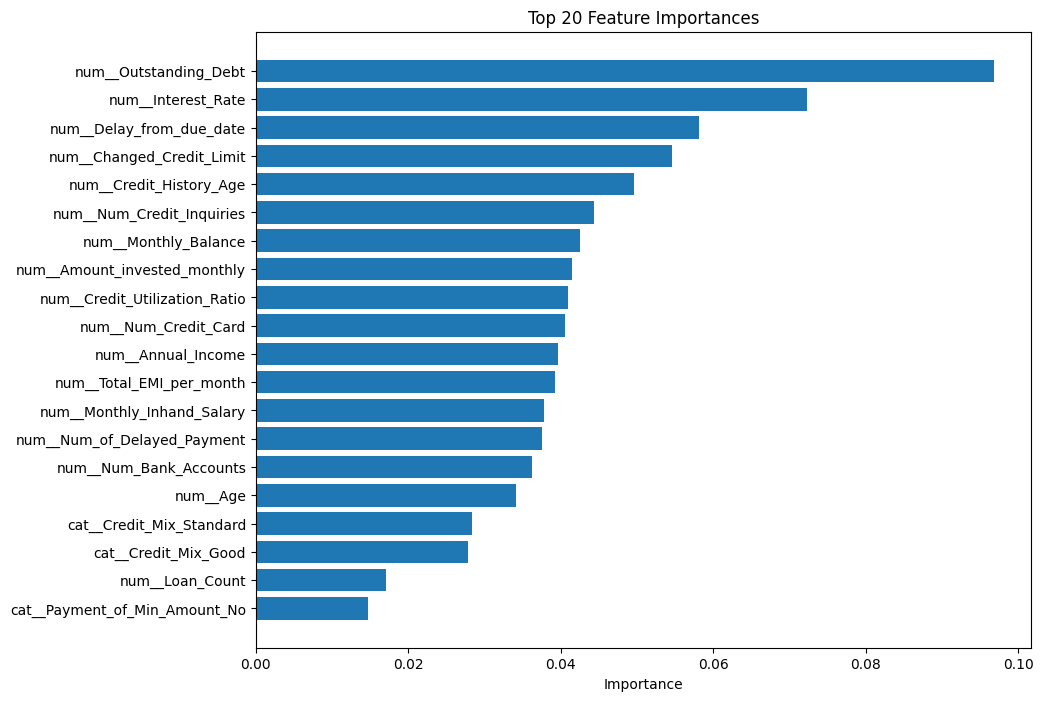

In [245]:
top20 = importance_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [246]:
importance_df.tail(20)

,Feature,Importance
46,cat__Payment_Behaviour_High_spent_Medium_value...,0.005404
49,cat__Payment_Behaviour_Low_spent_Medium_value_...,0.004877
32,cat__Occupation_Lawyer,0.004815
45,cat__Payment_Behaviour_High_spent_Large_value_...,0.004597
47,cat__Payment_Behaviour_High_spent_Small_value_...,0.004276
48,cat__Payment_Behaviour_Low_spent_Large_value_p...,0.004252
25,cat__Occupation_Accountant,0.003731
30,cat__Occupation_Entrepreneur,0.003553
29,cat__Occupation_Engineer,0.003456
38,cat__Occupation_Teacher,0.003449


coba untuk bikin merged or combined feature importance

In [247]:
grouped_importance = importance_df.copy()

grouped_importance["Feature"] = (
    grouped_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

grouped_importance["Feature"] = grouped_importance["Feature"].replace({
    r"Occupation_.*": "Occupation",
    r"Credit_Mix_.*": "Credit_Mix",
    r"Payment_of_Min_Amount_.*": "Payment_of_Min_Amount",
    r"Payment_Behaviour_.*": "Payment_Behaviour"
}, regex=True)

grouped_importance = (
    grouped_importance
    .groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

print(grouped_importance)

                     Feature  Importance
22          Outstanding_Debt    0.096821
12             Interest_Rate    0.072325
7                 Credit_Mix    0.061718
10       Delay_from_due_date    0.058112
4       Changed_Credit_Limit    0.054550
21                Occupation    0.052044
6         Credit_History_Age    0.049565
19      Num_Credit_Inquiries    0.044373
14           Monthly_Balance    0.042486
1    Amount_invested_monthly    0.041486
8   Credit_Utilization_Ratio    0.041000
18           Num_Credit_Card    0.040532
2              Annual_Income    0.039691
28       Total_EMI_per_month    0.039205
15     Monthly_Inhand_Salary    0.037814
20    Num_of_Delayed_Payment    0.037525
17         Num_Bank_Accounts    0.036246
0                        Age    0.034104
24         Payment_Behaviour    0.029923
25     Payment_of_Min_Amount    0.025664
13                Loan_Count    0.017131
5        Credit_Builder_Loan    0.006117
23               Payday_Loan    0.006062
16             M

### Hasil Lanjutan RF BASELINE FEATURE IMPORTANCE


Alasan baseline RF memakai fitur dalam jumlah besar:

- Baseline Random Forest dilatih menggunakan seluruh 29 kolom hasil feature selection (belum ada pengurangan fitur manual) --> tujuannya supaya model punya akses penuh ke seluruh informasi yang tersedia terlebih dahulu, sebelum dilakukan reduksi fitur berbasis bukti (feature importance), bukan berdasarkan tebakan fitur mana yang penting

- Setelah melalui ColumnTransformer (StandardScaler untuk numerik, OneHotEncoder untuk kategorikal), jumlah kolom aktual yang diproses model membengkak menjadi 46 kolom --> kolom kategorikal seperti Occupation (15 kategori) dan Payment_Behaviour (6 kategori) masing-masing pecah menjadi banyak kolom biner hasil one-hot encoding



Cara Random Forest "seharusnya" berperilaku:

- Secara default, setiap tree pada RandomForestClassifier tidak dibatasi kedalamannya (max_depth=None) dan terus tumbuh sampai leaf-nya murni --> training accuracy mendekati 1.0 adalah perilaku bawaan algoritma, bukan indikasi pipeline bermasalah

- Yang menjadi indikator kesehatan model bukan gap train-test accuracy, melainkan konsistensi skor pada data yang belum pernah dilihat model (test set dan cross-validation)


- Hasil RandomizedSearchCV menunjukkan CV accuracy sebesar 0.7266 dan test accuracy tuned model sebesar 0.749, keduanya berdekatan dengan test accuracy baseline (0.7498) --> mengindikasikan performa model stabil di berbagai subset data, bukan hasil kebetulan dari satu split tertentu


- Nilai importance yang terlihat kecil (skala 0.01-0.09) merupakan efek normalisasi, bukan tanda fitur tidak relevan --> importance di-normalisasi supaya total seluruh 46 kolom berjumlah 1, sehingga rata-rata importance per kolom hanya sekitar 1/46 = 0.022

- Fitur-fitur teratas berada 2-4 kali di atas rata-rata tersebut, yang berarti kontribusinya tetap signifikan secara relatif


- Kolom kategorikal seperti Credit_Mix dan Payment_Behaviour terlihat kecil per kategori karena satu variabel aslinya pecah menjadi beberapa kolom one-hot --> ketika digabungkan kembali per variabel asal (grouped importance), Credit_Mix menjadi 0.0617 dan Occupation menjadi 0.0520, jauh lebih tinggi dibanding tampilan per-kolom individualnya


- Fitur dengan importance tertinggi (Outstanding_Debt, Interest_Rate, Delay_from_due_date, Changed_Credit_Limit) secara konsep memang berkaitan langsung dengan kapasitas dan riwayat bayar nasabah --> konsisten dengan variabel yang lazim dipakai dalam penilaian credit scoring di institusi keuangan, sehingga hasil ini masuk akal secara domain, bukan sekadar artefak overfitting


- Distribusi importance yang tersebar ke banyak fitur finansial (bukan terkonsentrasi di satu fitur dominan) juga merupakan indikasi model menangkap pola credit risk yang bersifat multi-faktor, sesuai dengan sifat data credit scoring pada umumnya

Alasan melanjutkan dengan RF baseline (bukan hasil tuning):
- RandomizedSearchCV pada Random Forest menghasilkan test accuracy 0.749, hampir identik dengan RF baseline (0.7498) --> tidak ada peningkatan performa yang cukup berarti untuk membenarkan penggunaan model hasil tuning


- Karena performa keduanya setara, RF baseline dipertahankan sebagai model final --> lebih sederhana secara konfigurasi dan tidak memerlukan proses tuning tambahan setiap kali model perlu dilatih ulang, tanpa mengorbankan akurasi.

### Streamlit Feature Set

ini hasil dari feature importance, variable apa aja yang bakal dipakai di streamlit

karena ga mungkin seseorang bisa inget atau mau menjawab/mengisi semua variabel yang ada

In [248]:
streamlit_features = [
    "Age",
    "Occupation",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Delay_from_due_date",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Credit_Mix",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age",
    "Total_EMI_per_month",
    "Monthly_Balance",
    "Payment_of_Min_Amount",
    "Loan_Count",
    "Credit_Score"
]

df_streamlit = df[streamlit_features].copy()

In [249]:
X_streamlit = df_streamlit.drop("Credit_Score", axis=1)
y_streamlit = df_streamlit["Credit_Score"]

In [250]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_streamlit,
    y_streamlit,
    test_size=0.2,
    random_state=42,
    stratify=y_streamlit
)

In [251]:
categorical_cols_s = X_train_s.select_dtypes(include="object").columns.tolist()
numerical_cols_s = X_train_s.select_dtypes(exclude="object").columns.tolist()

In [252]:
preprocessor_s = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols_s),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_s)
    ]
)

In [253]:
rf_streamlit = Pipeline([
    ("preprocessor", preprocessor_s),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [254]:
rf_streamlit.fit(X_train_s, y_train_s)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income',
                                                   'Monthly_Inhand_Salary',
                                                   'Num_Bank_Accounts',
                                                   'Num_Credit_Card',
                                                   'Interest_Rate',
                                                   'Delay_from_due_date',
                                                   'Changed_Credit_Limit',
                                                   'Num_Credit_Inquiries',
                                                   'Outstanding_Debt',
                                                   'Credit_Utilization_Ratio',
                                                   'Credit_History_Age',
                                                   'Total_EMI_per_month',
                                                   'Monthly_Balance',
                                                   'Loan_Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Occupation', 'Credit_Mix',
                                                   'Payment_of_Min_Amount'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [255]:
y_pred_s = rf_streamlit.predict(X_test_s)

In [256]:
print("Accuracy RF Streamlit:", accuracy_score(y_test_s, y_pred_s))
print(classification_report(y_test_s, y_pred_s))
print(confusion_matrix(y_test_s, y_pred_s))

Accuracy RF Streamlit: 0.734
              precision    recall  f1-score   support

        Good       0.64      0.68      0.66       909
        Poor       0.74      0.71      0.73      1440
    Standard       0.76      0.77      0.77      2651

    accuracy                           0.73      5000
   macro avg       0.71      0.72      0.72      5000
weighted avg       0.74      0.73      0.73      5000

[[ 614   16  279]
 [  68 1024  348]
 [ 283  336 2032]]


In [257]:
print("Training Accuracy:", rf_streamlit.score(X_train_s, y_train_s))
print("Testing Accuracy :", rf_streamlit.score(X_test_s, y_test_s))

Training Accuracy: 1.0
Testing Accuracy : 0.734


### Model Streamlit


- Berdasarkan hasil feature importance, dibangun subset fitur yang lebih ringkas dengan menghilangkan fitur-fitur berimportance rendah, terutama kolom biner jenis pinjaman individual --> bertujuan mengurangi jumlah input yang perlu diisi pengguna pada aplikasi Streamlit, sekaligus mempertahankan fitur-fitur dengan kontribusi prediktif terbesar


- Random Forest yang dilatih ulang dengan subset fitur ini menghasilkan accuracy 0.734 pada test set, sedikit lebih rendah dibanding model dengan fitur lengkap (0.7498), dengan selisih relatif kecil (sekitar 1.6 poin persentase) --> menunjukkan sebagian besar sinyal prediktif terhadap Credit_Score memang terkonsentrasi pada fitur-fitur dengan importance tinggi, sehingga pengurangan jumlah fitur dapat dilakukan tanpa penurunan performa yang signifikan


- Baik model baseline maupun model dengan subset fitur menunjukkan training accuracy 1.0 sementara testing accuracy berada di kisaran 0.73-0.75 --> gap ini merupakan indikasi overfitting yang umum terjadi pada Random Forest tanpa batasan depth, meskipun testing accuracy yang relatif stabil pada kedua model menunjukkan generalisasi model masih cukup konsisten